# Ejercicio 3

### Ejercicio 3
En lo que sigue, consideraremos que la variable protegida a analizar será **género**.
Basándonos en trabajos que señalan ciertos sesgos de genéro, se propone:

*Nota del equipo: Como el dataset de Bank Marketing no tiene género, usamos el estado civil (marital) como proxy.*

a) Describir con palabras cómo se interpretan en este contexto los criterios de fairness vistos en clase: Statistical Parity, Equalized Odds, Equal Opportunity y Predictive Parity.


1. **Statistical Parity**: Vemos si llamamos a la misma proporción de gente en ambos grupos. Por ejemplo, si llamamos al 10% de los casados y al 10% de los solteros, hay paridad. No importa si se iban a suscribir o no.
   
2. **Equal Opportunity**: Este nos importa más. Mira solo a la gente que **sí** se iba a suscribir. Queremos que el modelo los encuentre igual de bien tanto si son casados como si no. O sea, el Recall tiene que ser parecido.

3. **Equalized Odds**: Es más exigente, pide que el Recall sea igual y también que los errores de llamar a alguien al divino botón (Falsos Positivos) sean iguales para los dos grupos.

4. **Predictive Parity**: Acá miramos la Precisión. Si el modelo dice "este cliente se suscribe", ¿qué tan confiables somos? Esa confianza tiene que ser la misma para ambos grupos.


b) Considerando como medida de disparidad el módulo de la diferencia y seleccionando un umbral definido por ustedes, analizar si el modelo inicial es fair para cada una de las posibles definiciones de fairness estudiadas en el inciso anterior.

In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, accuracy_score

# Cargamos los datos
df = pd.read_csv('data/full.csv', sep=';')

# Preprocesamiento
from sklearn.preprocessing import LabelEncoder
df_enc = df.copy()
le = LabelEncoder()
for col in df_enc.select_dtypes(include=['object']).columns:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

X = df_enc.drop(columns=['y'])
y = df_enc['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)


--- Métricas por Grupo ---
         Statistical Parity  Equal Opportunity (Recall)  \
grupo                                                     
Casados            0.078392                    0.537109   
Otros              0.101134                    0.531250   

         Predictive Parity (Precision)  FPR (Equalized Odds)  
grupo                                                         
Casados                       0.705128              0.025767  
Otros                         0.669697              0.038286  

--- ¿Pasan el umbral de 0.1? ---
Statistical Parity               True
Equal Opportunity (Recall)       True
Predictive Parity (Precision)    True
FPR (Equalized Odds)             True
dtype: bool


C:\Users\tomas\AppData\Local\Temp\ipykernel_21188\1758374753.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metricas_por_grupo = resultados.groupby('grupo').apply(calcular_metricas)


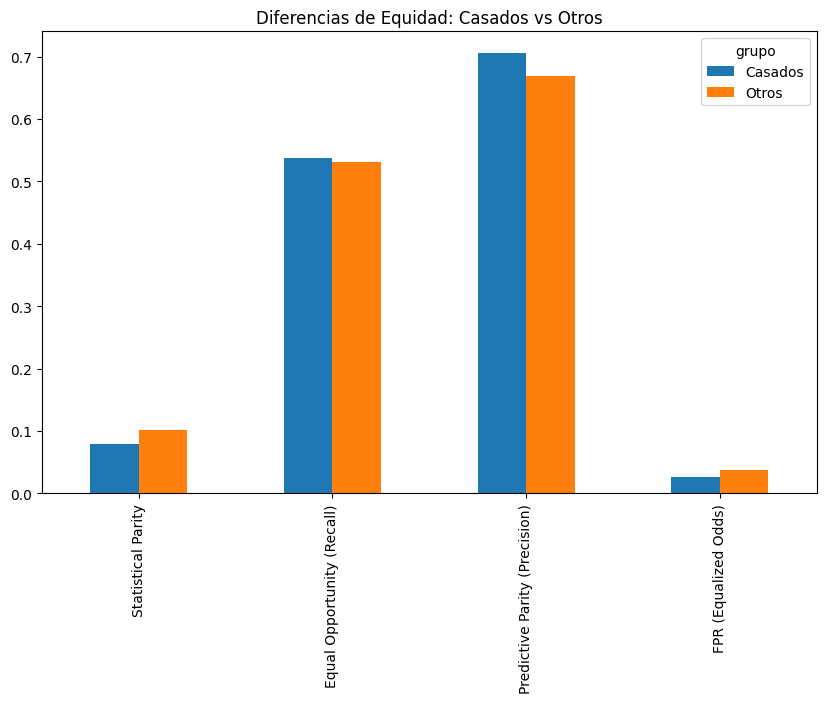

In [7]:

# Cálculo manual de métricas por grupo
resultados = pd.DataFrame({
    'marital_orig': df.loc[X_test.index, 'marital'],
    'y_true': y_test,
    'y_pred': y_pred
})
resultados['grupo'] = resultados['marital_orig'].apply(lambda x: 'Casados' if x == 'married' else 'Otros')

def calcular_metricas(df_grupo):
    paridad_est = df_grupo['y_pred'].mean()
    recall = recall_score(df_grupo['y_true'], df_grupo['y_pred'], zero_division=0)
    precision = precision_score(df_grupo['y_true'], df_grupo['y_pred'], zero_division=0)
    
    # FPR para Equalized Odds
    def get_fpr(yt, yp):
        fp = ((yt == 0) & (yp == 1)).sum()
        tn = ((yt == 0) & (yp == 0)).sum()
        return fp / (fp + tn) if (fp + tn) > 0 else 0
        
    return pd.Series({
        'Statistical Parity': paridad_est,
        'Equal Opportunity (Recall)': recall,
        'Predictive Parity (Precision)': precision,
        'FPR (Equalized Odds)': get_fpr(df_grupo['y_true'], df_grupo['y_pred'])
    })

metricas_por_grupo = resultados.groupby('grupo').apply(calcular_metricas)
print("--- Métricas por Grupo ---")
print(metricas_por_grupo)

diferencias = (metricas_por_grupo.loc['Casados'] - metricas_por_grupo.loc['Otros']).abs()
umbral = 0.1
print(f"\n--- ¿Pasan el umbral de {umbral}? ---")
print(diferencias < umbral)

# Grafiquito
metricas_por_grupo.T.plot(kind='bar', figsize=(10, 6))
plt.title('Diferencias de Equidad: Casados vs Otros')
plt.show()


c) Recordando que forman parte de la entidad asignada en cada conjunto de datos, ¿cuál de los criterios de fairness le parece relevante en este contexto? Justificar su elección.


En este contexto de marketing bancario, nosotros creemos que el mejor criterio es **Equal Opportunity (Igualdad de Oportunidades)**.

Nos interesa que si un cliente realmente tiene perfil para suscribirse (lo que es bueno para él y para el banco), el modelo lo identifique sin importar su estado civil. No nos molesta llamar a más personas de un grupo si hay más interesados en ese grupo, pero sí sería injusto que el modelo "ignore" a los interesados de un grupo específico.


### Ejercicio 3
